In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## Import data
customers_df = pd.read_csv('customers.csv')
Items_df = pd.read_csv('Items.csv')
order_item_df = pd.read_csv('order_item.csv')
orders_df = pd.read_csv('orders.csv')

In [3]:
copy_customers_df = customers_df.copy()
copy_items_df = Items_df.copy()
copy_order_item_df = order_item_df.copy()
copy_orders_df = orders_df.copy()

In [4]:
# EX_1_a
duplicate_items = copy_items_df[copy_items_df.duplicated(subset=['item_name', 'item_brand'], keep=False)]
duplicate_items

,id,item_name,item_category,item_price,stock_quantity,item_brand,item_availability


In [5]:
# copy_items_df[['item_name', 'item_brand']]

items_with_brand = copy_items_df.dropna(subset=['item_brand'])  
items_without_brand = copy_items_df[copy_items_df['item_brand'].isna()] 

duplicates_name_no_brand = items_without_brand[items_without_brand['item_name'].isin(items_with_brand['item_name'])]

duplicates_name_no_brand


,id,item_name,item_category,item_price,stock_quantity,item_brand,item_availability
7,8,Headphone,NaN,3117.19,599.0,NaN,True


In [6]:
copy_items_df.set_index('id', inplace=True)
copy_order_item_df.set_index('id', inplace=True)
copy_items_df.drop(duplicates_name_no_brand.index, axis=0, inplace=True)
copy_order_item_df.drop(duplicates_name_no_brand.index, axis=0, inplace=True)
copy_items_df.reset_index('id', inplace=True)
copy_order_item_df.reset_index('id', inplace=True)


In [7]:
duplicates_name_brand = copy_items_df[copy_items_df.duplicated(subset=['item_name', 'item_brand'], keep=False)]
duplicates_name_brand


,id,item_name,item_category,item_price,stock_quantity,item_brand,item_availability


In [8]:
# EX1_b
duplicate_customers = copy_customers_df[copy_customers_df.duplicated(subset=['email'], keep=False)]
duplicate_customers

,id,first_name,last_name,gender,age,nationallity,joining_date,phone_number,email


In [9]:
#EX1_d
missing_data_customers = copy_customers_df.isnull().sum()
percentage_missing_customers = copy_customers_df.isnull().sum() * 100 / copy_customers_df.isnull().count() 
print(percentage_missing_customers)

## Fill missing data with default values:
copy_customers_df['gender'] = copy_customers_df['gender'].fillna('Male')
copy_customers_df['joining_date'] = copy_customers_df['joining_date'].fillna(pd.to_datetime('2019-01-01'))

# I chose to add the date 1.1.2019 so as not to affect the distribution of the data
copy_customers_df['age'] = copy_customers_df['age'].fillna(round(copy_customers_df['age'].mean())) 


id               0.0
first_name       0.0
last_name        0.0
gender          10.6
age              5.0
nationallity     0.0
joining_date    12.2
phone_number     0.0
email            0.0
dtype: float64


In [10]:
missing_data_items = copy_items_df.isnull().sum()
percentage_missing_items = copy_items_df.isnull().sum() * 100 / copy_items_df.isnull().count() 
print(percentage_missing_items)

## Fill missing data with default values:
copy_items_df['item_category'] = copy_items_df['item_category'].fillna('Electronics')
copy_items_df['stock_quantity'] = copy_items_df['stock_quantity'].fillna(0)
copy_items_df['item_brand'] = copy_items_df['item_brand'].fillna('Nall')

id                    0.000000
item_name             0.000000
item_category        16.326531
item_price            0.000000
stock_quantity       10.204082
item_brand            6.122449
item_availability     0.000000
dtype: float64


In [11]:
missing_data_order_item = copy_order_item_df.isnull().sum()
percentage_missing_order_item = copy_order_item_df.isnull().sum() * 100 / copy_order_item_df.isnull().count() 
print(percentage_missing_order_item)

# Deleting the row because there is no vote for other items
copy_order_item_df = copy_order_item_df.dropna(subset=['item_id'])

id            0.000000
Unnamed: 0    0.000000
order_id      0.000000
item_id       4.004004
quantity      0.000000
dtype: float64


In [12]:
missing_data_order = copy_orders_df.isnull().sum()
percentage_missing_order = copy_orders_df.isnull().sum() * 100 / copy_orders_df.isnull().count() 
print(percentage_missing_order)

## Fill missing data with default values:
copy_orders_df['customer_id'] = copy_orders_df['customer_id'].fillna(0)
# I chose to fill in the customer name with 0 because it does not exist.
copy_orders_df['delivery_days'] = copy_orders_df['delivery_days'].fillna(round(copy_orders_df['delivery_days'].max()+10)) 
# I decided to add 10 to the maximum so that I wouldn't have to change the data immediately so that I could download it more easily later.

order_id             0.0
customer_id          7.5
delivery_address     0.0
delivery_days       12.5
order_date           0.0
payment_method       0.0
order_source         0.0
dtype: float64


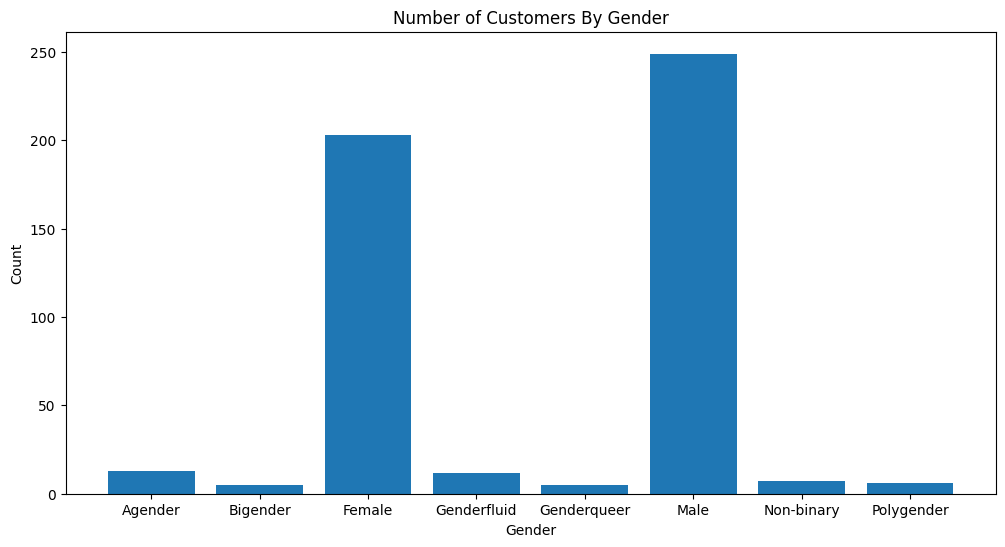

In [13]:
# EX_ Data analysis 1
gender_counts = copy_customers_df['gender'].value_counts().reset_index()
# print(gender_counts)
df_gender_count = copy_customers_df.groupby('gender').size()
df_gender_count = df_gender_count.reset_index(name='count')

plt.figure(figsize=(12,6))
plt.bar(df_gender_count['gender'], df_gender_count['count'])
plt.title('Number of Customers By Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()
# missing_data_customers



# I added another 53 people whose gender was defined as male.

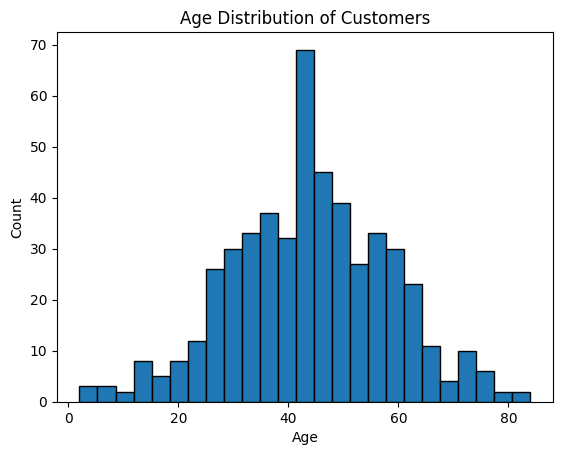

In [14]:
# print(missing_data_customers)
plt.hist(copy_customers_df['age'], bins=25, edgecolor='black')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Earlier I added another 25 Andes in average age.

In [15]:
yearly_customers = pd.to_datetime(copy_customers_df['joining_date']).dt.year.value_counts()

print(yearly_customers)

joining_date
2022    163
2021    138
2020    138
2019     61
Name: count, dtype: int64


# The year with the most customers participating is 2022 with 163 customers.

# According to the data, we can see that the number of customers is only increasing year by year, and we can see this in the graph.



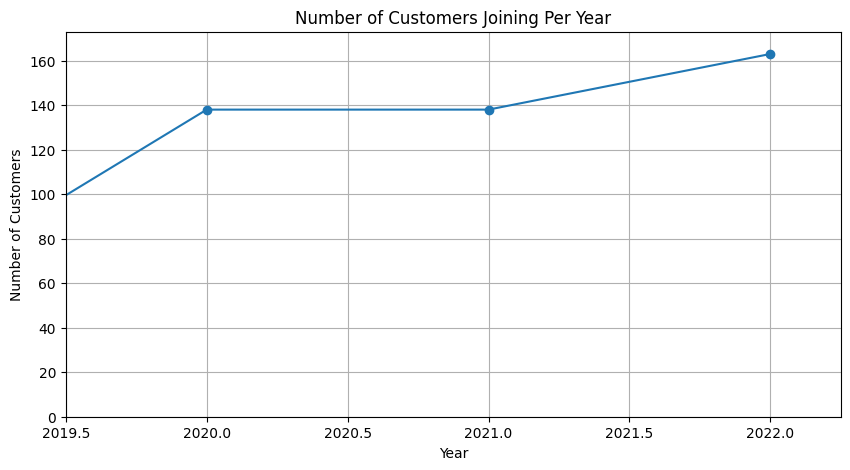

In [16]:
yearly_customers = yearly_customers.sort_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly_customers.index, yearly_customers.values, marker='o', linestyle='-')

plt.title('Number of Customers Joining Per Year')
plt.xlabel('Year')
plt.xlim(2019.5,2022.25)
plt.ylabel('Number of Customers')
plt.ylim(0, yearly_customers.max() + 10)
plt.grid(True)

plt.show()


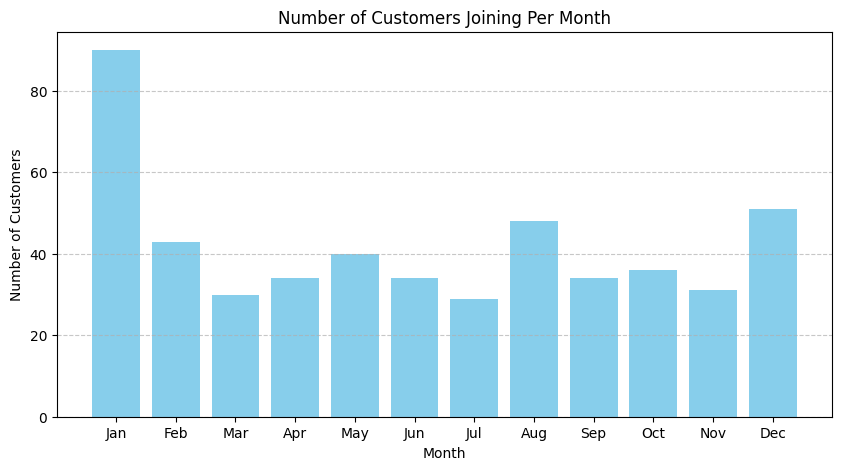

id               0
first_name       0
last_name        0
gender          53
age             25
nationallity     0
joining_date    61
phone_number     0
email            0
dtype: int64


In [17]:
monthly_customers = pd.to_datetime(copy_customers_df['joining_date']).dt.month.value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(monthly_customers.index, monthly_customers.values, color='skyblue')

plt.title('Number of Customers Joining Per Month')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(missing_data_customers)


##  The month in which the most customers joined was December. You can't see it from the graph because I added data incorrectly. In January, 61 more customers joined.

### Also, the number of customers who joined in the last year is the largest number in

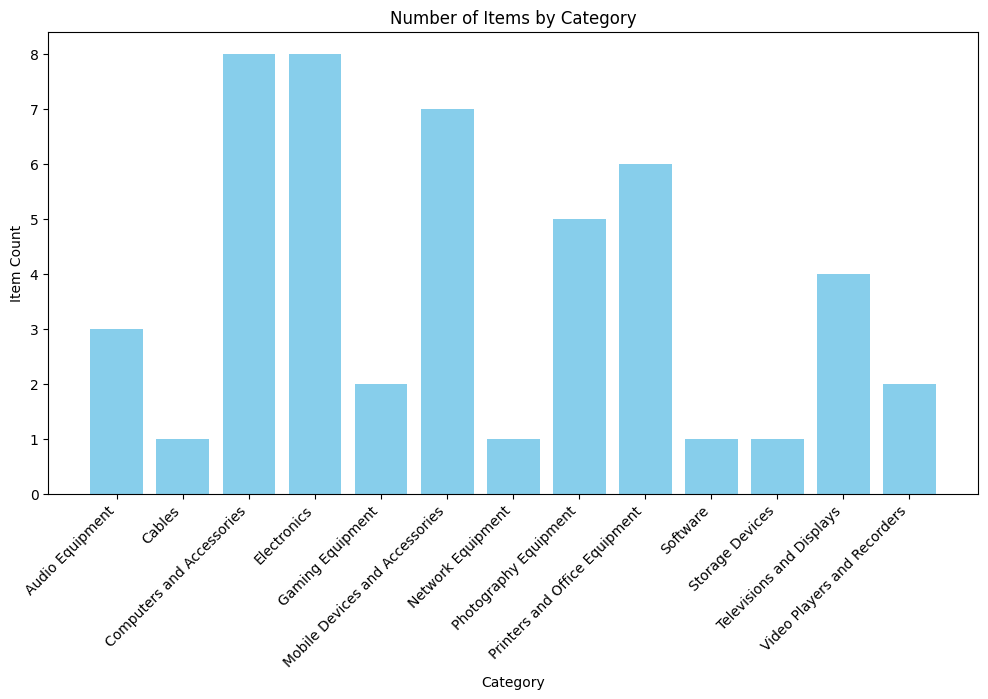

In [18]:
# EX_ 2
# Task (a): Count the number of items by category
category_counts = copy_items_df.groupby("item_category")["id"].count().reset_index()
category_counts.columns = ["Category", "Item Count"]
# Plot bar chart for item count by category
plt.figure(figsize=(12, 6))
plt.bar(category_counts["Category"], category_counts["Item Count"], color='skyblue')
plt.xlabel("Category")
plt.ylabel("Item Count")
plt.title("Number of Items by Category")
plt.xticks(rotation=45, ha='right')
plt.show()



## I added electronics, so you shouldn't take that into account.

In [19]:
# Remove rows where stock_quantity is 0
stock_quantity_filtered_df = copy_items_df[copy_items_df["stock_quantity"] > 0]

stock_quantity_df = stock_quantity_filtered_df[["item_name", "stock_quantity"]].sort_values(by="stock_quantity", ascending=False)

stock_quantity_df.head()


,item_name,stock_quantity
39,VR Headset,1367.0
7,Speaker,1360.0
20,USB Flash Drive,1251.0
37,Power Strip,1211.0
16,Computer Monitor,1205.0


In [20]:
stock_quantity_df.tail()

,item_name,stock_quantity
45,Printer,239.0
3,Smartphone,201.0
30,Portable Charger,192.0
4,Tablet,190.0
33,Wi-Fi Router,14.0


In [21]:
average_stock_quantity = stock_quantity_filtered_df["stock_quantity"].mean()
print(average_stock_quantity)


749.6363636363636


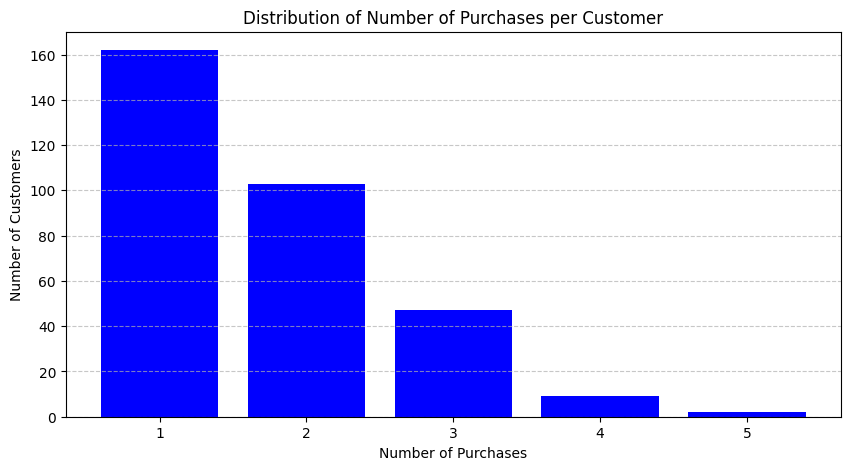

In [22]:
#EX_3
customer_order_counts = copy_orders_df['customer_id'].value_counts()

# Count occurrences of each order frequency
order_frequency_counts = customer_order_counts.value_counts().sort_index()
# Filter out the outlier (e.g., customers with more than 10 purchases)
filtered_order_frequency_counts = order_frequency_counts[order_frequency_counts.index <= 40]

# Plot bar chart
plt.figure(figsize=(10, 5))
plt.bar(filtered_order_frequency_counts.index, filtered_order_frequency_counts.values, color='blue')
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.title("Distribution of Number of Purchases per Customer")
plt.xticks(filtered_order_frequency_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [23]:
top_5_customers = customer_order_counts.head(6).reset_index()
top_5_customers.columns = ['customer_id', 'order_count']
top_5_customers.head(6)

,customer_id,order_count
0,0.0,45
1,59.0,5
2,138.0,5
3,151.0,4
4,286.0,4
5,274.0,4


## There is no customer 0 I have configured auth to balance the data

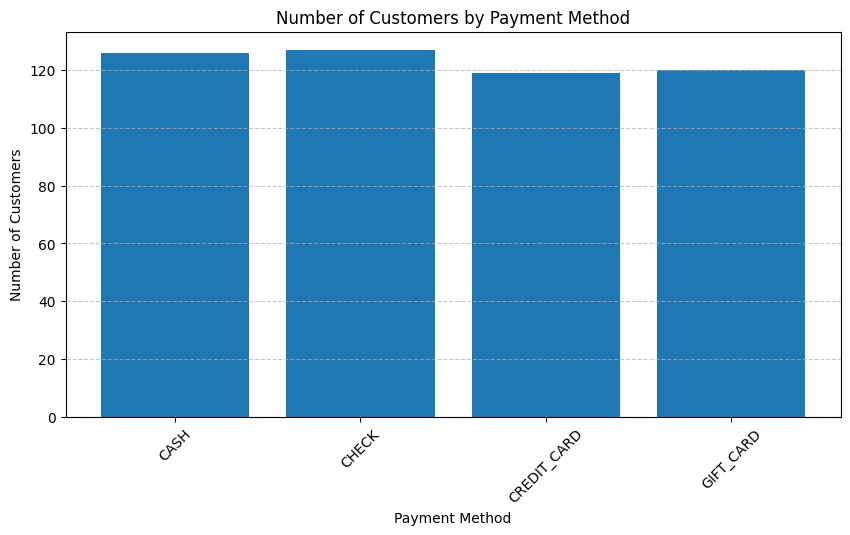

In [24]:
# Recalculate payment method counts
payment_method_counts = copy_orders_df.groupby('payment_method')['customer_id'].nunique()

plt.figure(figsize=(10, 5))
plt.bar(payment_method_counts.index, payment_method_counts.values)
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.title("Number of Customers by Payment Method")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [25]:
# EX_4
order_item_merged = copy_order_item_df.merge(copy_items_df[['id', 'item_price']], left_on='item_id', right_on='id', how='left')
order_item_merged['total_price'] = order_item_merged['item_price'] * order_item_merged['quantity']
order_totals = order_item_merged.groupby('order_id')['total_price'].sum().reset_index()
copy_orders_df = copy_orders_df.merge(order_totals, on='order_id', how='left')
copy_orders_df = copy_orders_df.rename(columns={'total_price': 'order_total_price'})

print(copy_orders_df[['order_id', 'order_total_price']].head(5))



   order_id  order_total_price
0         1            8554.20
1         2           10148.58
2         3            6843.36
3         4             965.20
4         5           37911.02


In [26]:
max_total_price = copy_orders_df['order_total_price'].max()
min_total_price = copy_orders_df['order_total_price'].min()
mean_total_price = copy_orders_df['order_total_price'].mean()

print(f"Highest Order Price: {max_total_price}")
print(f"Lowest Order Price: {min_total_price}")
print(f"Average Order Price: {mean_total_price}")

Highest Order Price: 81267.68
Lowest Order Price: 0.0
Average Order Price: 14528.949105504586


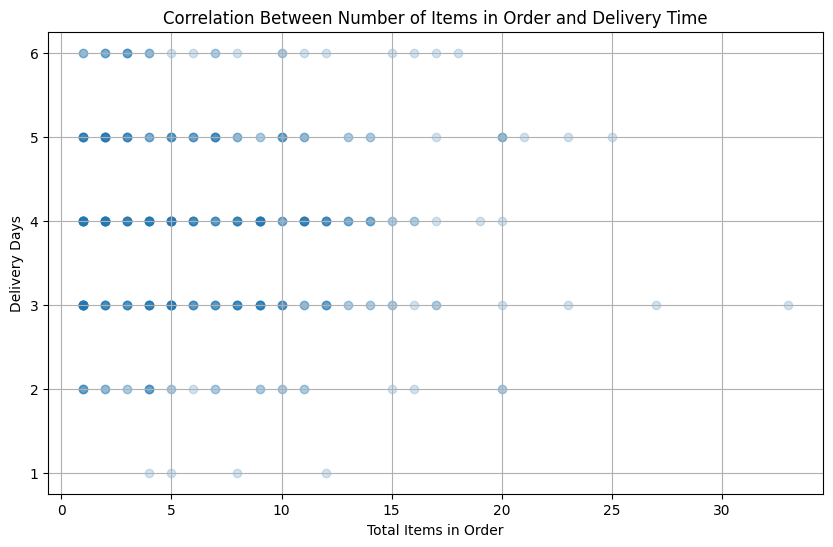

In [27]:

order_item_counts = copy_order_item_df.groupby('order_id')['quantity'].sum().reset_index()
order_item_counts.rename(columns={'quantity': 'total_items'}, inplace=True)


order_delivery_data = copy_orders_df.merge(order_item_counts, on='order_id', how='left')
filtered_order_delivery_data = order_delivery_data[order_delivery_data['delivery_days'] < 10]

plt.figure(figsize=(10, 6))
plt.scatter(filtered_order_delivery_data['total_items'], filtered_order_delivery_data['delivery_days'], alpha=0.2)
plt.xlabel('Total Items in Order')
plt.ylabel('Delivery Days')
plt.title('Correlation Between Number of Items in Order and Delivery Time')
plt.grid(True)

# Show the plot
plt.show()

## You can see that no matter how many products are ordered, the lead time is usually 3 or 4 days.

In [36]:
customers_with_orders = copy_orders_df['customer_id'].unique()
customers_without_orders = copy_customers_df[copy_customers_df['id'].isin(customers_with_orders)]

print(f"Number of customers who never placed an order: {customers_without_orders.shape[0]}")


Number of customers who never placed an order: 323


In [37]:

item_order_counts = copy_order_item_df.groupby('item_id')['quantity'].sum().reset_index()
lowest_ordered_items = item_order_counts.sort_values(by='quantity', ascending=True)
lowest_ordered_items = lowest_ordered_items.merge(copy_items_df[['id', 'item_name']], left_on='item_id', right_on='id', how='left')
lowest_ordered_items = lowest_ordered_items[['item_id', 'item_name', 'quantity']]

print("Top 5 Least Ordered Items:")
print(lowest_ordered_items.head(5))


Top 5 Least Ordered Items:
   item_id            item_name  quantity
0     29.0               Webcam        25
1     33.0      Surge Protector        27
2     21.0  External Hard Drive        33
3     28.0          CCTV Camera        34
4     30.0         Gaming Chair        37


In [38]:
print("Top 5 high Ordered Items:")
print(lowest_ordered_items.tail(5))

Top 5 high Ordered Items:
    item_id        item_name  quantity
45     38.0  Office Software        78
46     16.0            Drone        79
47     34.0       HDMI Cable        80
48     20.0            Mouse        82
49     50.0          Speaker        93
